# Phase 1 — YOLOv8 Baseline

First real attempt at the challenge. The plan is to get a working YOLO pipeline end-to-end as a baseline — nothing fancy, no ensembles, no tricks. Just train `yolov8m-p2`, validate, and submit. The point is to put a number on the board that everything else can be compared against.

I'm going with the **P2 variant** specifically because EDA showed ~49% of boxes are smaller than 32² pixels — without the extra stride-8 head YOLO would just miss most of them.

In [1]:
# Install / upgrade ultralytics if not present
try:
    import ultralytics
    print(f"ultralytics {ultralytics.__version__} already installed")
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "ultralytics"], check=True)
    import ultralytics
    print(f"Installed ultralytics {ultralytics.__version__}")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Victor\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.37 already installed


In [2]:
import json
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT        = Path("data")
IMG_TRAIN   = ROOT / "images" / "train"
IMG_TEST    = ROOT / "images" / "test"
ANN_FILE    = ROOT / "annotations" / "instances_train.json"
LBL_TRAIN   = ROOT / "labels"  / "train"   # YOLO .txt files go here

LBL_TRAIN.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Train images:", len(list(IMG_TRAIN.glob("*.png"))))
print("Test  images:", len(list(IMG_TEST.glob("*.png"))))

Train images: 3154
Test  images: 786


## COCO → YOLO label conversion

The dataset ships in COCO JSON format but YOLO wants one `.txt` per image with normalised `class cx cy w h` lines. Straightforward conversion — the only gotcha is that the 34 negative samples (images with no RFI) need empty `.txt` files, not missing files. Otherwise Ultralytics treats them as unlabeled and silently drops them from training.

In [3]:
with open(ANN_FILE) as f:
    coco = json.load(f)

# Build lookup: image_id → (filename, width, height)
img_meta = {img["id"]: img for img in coco["images"]}

# Group annotations by image_id
from collections import defaultdict
ann_by_img = defaultdict(list)
for ann in coco["annotations"]:
    ann_by_img[ann["image_id"]].append(ann["bbox"])  # [x_min, y_min, w, h]

converted = 0
for img_id, meta in img_meta.items():
    stem = Path(meta["file_name"]).stem          # e.g. "42"
    iw, ih = meta["width"], meta["height"]
    boxes = ann_by_img[img_id]                   # may be empty

    lines = []
    for x, y, w, h in boxes:
        cx = (x + w / 2) / iw
        cy = (y + h / 2) / ih
        nw = w / iw
        nh = h / ih
        # Clamp to [0, 1] — occasional label noise
        cx, cy, nw, nh = (
            min(max(cx, 0), 1), min(max(cy, 0), 1),
            min(max(nw, 0), 1), min(max(nh, 0), 1),
        )
        lines.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

    lbl_path = LBL_TRAIN / f"{stem}.txt"
    lbl_path.write_text("\n".join(lines))
    converted += 1

print(f"Wrote {converted} label files → {LBL_TRAIN}")
print(f"  Negative samples (empty labels): {sum(1 for p in LBL_TRAIN.glob('*.txt') if p.stat().st_size == 0)}")

Wrote 3154 label files → data\labels\train
  Negative samples (empty labels): 34


### Sanity check

Quick overlay of a few converted labels onto their images to make sure normalisation and the coordinate-system conversion didn't get flipped somewhere.

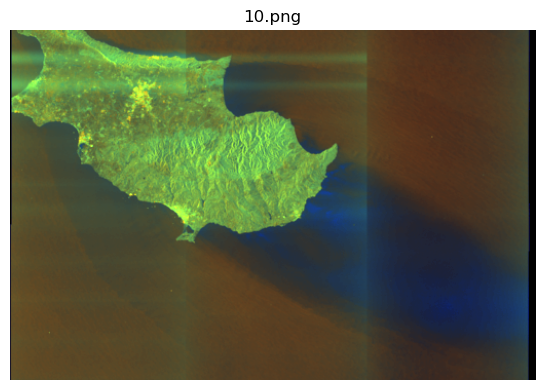

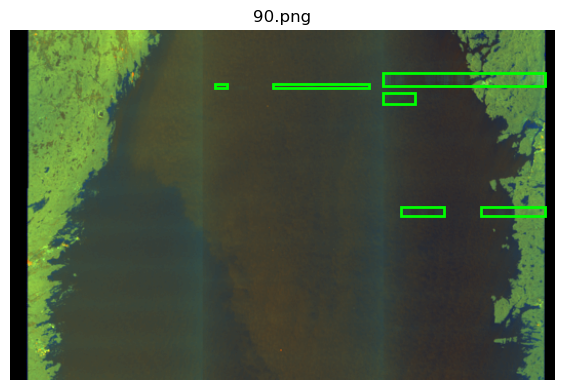

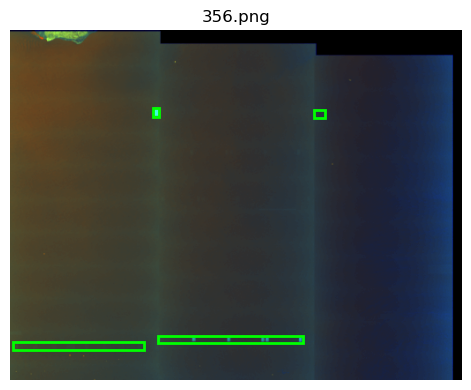

In [4]:
import matplotlib.patches as mpatches

def show_yolo_label(img_path: Path, lbl_path: Path):
    img = Image.open(img_path)
    iw, ih = img.size
    fig, ax = plt.subplots(1, figsize=(8, 4))
    ax.imshow(img)
    for line in lbl_path.read_text().splitlines():
        if not line.strip():
            continue
        _, cx, cy, nw, nh = map(float, line.split())
        x = (cx - nw / 2) * iw
        y = (cy - nh / 2) * ih
        rect = mpatches.Rectangle((x, y), nw * iw, nh * ih,
                                   linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(img_path.name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Pick a few images that have annotations
sample_ids = [10, 90, 356]
for sid in sample_ids:
    show_yolo_label(IMG_TRAIN / f"{sid}.png", LBL_TRAIN / f"{sid}.txt")

## K-means anchor analysis

YOLOv8 is anchor-free, so this isn't strictly necessary — but I want to see the aspect-ratio clusters in pixel space and confirm two things:
- The bulk of boxes really do cluster at high aspect ratios (i.e. thin horizontal stripes), justifying the custom augmentation choices later
- A meaningful share of boxes are small enough that the P2 head matters

Total boxes: 9288

K-means anchors (w × h, sorted by width):
  1: 18.5 × 8.4  (AR=2.2)
  2: 52.3 × 10.0  (AR=5.2)
  3: 110.4 × 10.2  (AR=10.9)
  4: 150.9 × 11.7  (AR=12.9)
  5: 161.1 × 103.4  (AR=1.6)
  6: 162.0 × 205.0  (AR=0.8)
  7: 163.4 × 320.8  (AR=0.5)
  8: 172.3 × 13.5  (AR=12.8)
  9: 374.0 × 32.8  (AR=11.4)


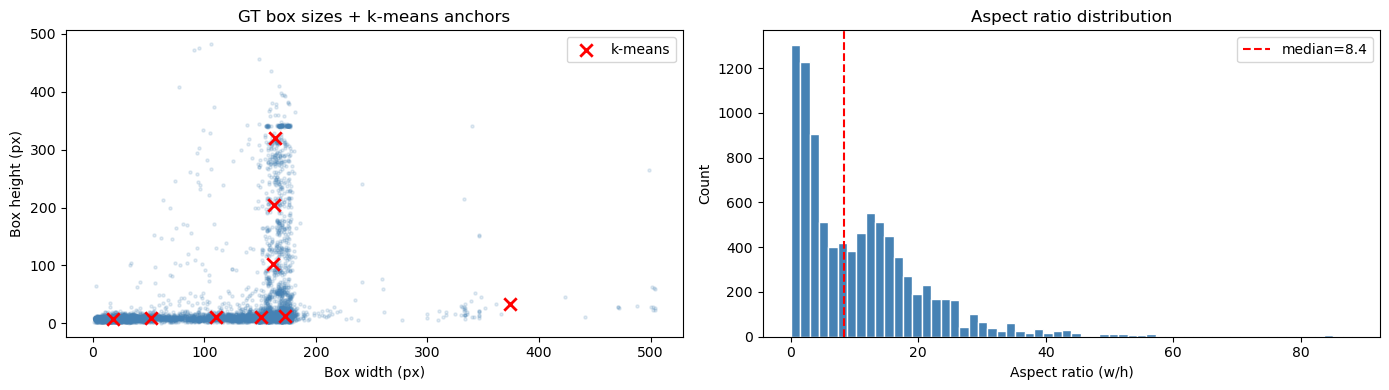


COCO size split → Small: 48.8%  Medium: 43.0%  Large: 8.2%
→ P2 head (stride 8) is required to detect the small/medium majority.


In [6]:
from sklearn.cluster import KMeans

# Collect all (w_px, h_px) from COCO annotations
boxes_px = np.array([[ann["bbox"][2], ann["bbox"][3]] for ann in coco["annotations"]])
print(f"Total boxes: {len(boxes_px)}")

# ── K-means in pixel space (k=9 like YOLOv5 default) ──────────────────────────
k = 9
km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(boxes_px)
anchors = km.cluster_centers_
anchors = anchors[np.argsort(anchors[:, 0])]  # sort by width

print("\nK-means anchors (w × h, sorted by width):")
for i, (w, h) in enumerate(anchors):
    print(f"  {i+1}: {w:.1f} × {h:.1f}  (AR={w/h:.1f})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(boxes_px[:, 0], boxes_px[:, 1], alpha=0.15, s=5, c="steelblue")
axes[0].scatter(anchors[:, 0], anchors[:, 1], c="red", s=80, marker="x", linewidths=2, label="k-means")
axes[0].set_xlabel("Box width (px)")
axes[0].set_ylabel("Box height (px)")
axes[0].set_title("GT box sizes + k-means anchors")
axes[0].legend()

aspect_ratios = boxes_px[:, 0] / np.maximum(boxes_px[:, 1], 1)
axes[1].hist(aspect_ratios, bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(np.median(aspect_ratios), color="red", linestyle="--", label=f"median={np.median(aspect_ratios):.1f}")
axes[1].set_xlabel("Aspect ratio (w/h)")
axes[1].set_ylabel("Count")
axes[1].set_title("Aspect ratio distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── COCO size breakdown ────────────────────────────────────────────────────────
areas = boxes_px[:, 0] * boxes_px[:, 1]
small  = (areas < 32**2).mean() * 100
medium = ((areas >= 32**2) & (areas < 96**2)).mean() * 100
large  = (areas >= 96**2).mean() * 100
print(f"\nCOCO size split → Small: {small:.1f}%  Medium: {medium:.1f}%  Large: {large:.1f}%")
print("→ P2 head (stride 8) is required to detect the small/medium majority.")

## Train / Val split (90 / 10)

Random shuffle with a fixed seed (42) so the split is reproducible across phases. Writing absolute paths to `.txt` files — Ultralytics accepts those directly as the `train`/`val` keys in the dataset YAML, which avoids having to physically move images into separate folders.

In [21]:
all_img_paths = sorted(IMG_TRAIN.glob("*.png"))
random.shuffle(all_img_paths)

val_frac   = 0.10
n_val      = int(len(all_img_paths) * val_frac)
val_paths  = all_img_paths[:n_val]
train_paths = all_img_paths[n_val:]

print(f"Train: {len(train_paths)}   Val: {len(val_paths)}")

# Write absolute-path lists (Ultralytics accepts .txt lists)
SPLIT_DIR = ROOT.parent  # one level up → ClearSAR/
train_txt = SPLIT_DIR / "train_split.txt"
val_txt   = SPLIT_DIR / "val_split.txt"

train_txt.write_text("\n".join(str(p.resolve()) for p in train_paths))
val_txt.write_text(  "\n".join(str(p.resolve()) for p in val_paths))

print(f"Wrote {train_txt}")
print(f"Wrote {val_txt}")

Train: 2839   Val: 315
Wrote train_split.txt
Wrote val_split.txt


## Dataset YAML

The config Ultralytics actually consumes during training. Single class (`RFI`), points at the two split files. This same YAML gets reused in every subsequent phase.

In [22]:
import os

yaml_content = f"""# ClearSAR — RFI detection dataset
# Generated by phase_1.ipynb

train: {train_txt.resolve()}
val:   {val_txt.resolve()}

nc: 1
names: ['RFI']
"""

yaml_path = SPLIT_DIR / "clearsar.yaml"
yaml_path.write_text(yaml_content)
print(yaml_path.read_text())

# ClearSAR — RFI detection dataset
# Generated by phase_1.ipynb

train: C:\Users\Victor\Desktop\Projects\ESA_SAR\ClearSAR\train_split.txt
val:   C:\Users\Victor\Desktop\Projects\ESA_SAR\ClearSAR\val_split.txt

nc: 1
names: ['RFI']



## Train YOLOv8m-P2

The hyperparameters here are not default — most of them are direct consequences of the EDA:

| Parameter | Value | Why |
|-----------|-------|-----|
| model | `yolov8m-p2.yaml` + `yolov8m.pt` | COCO-pretrained backbone, randomly-initialized P2 head |
| imgsz | 640 | Tried 800 earlier — slightly worse, more memory. 640 is the sweet spot |
| degrees | 0 | Rotation breaks the horizontal-stripe semantics |
| flipud | 0 | Same — vertical flip turns a stripe into something physically impossible |
| fliplr | 0.5 | Safe — the spatial prior is symmetric around x=0.5 |
| mosaic | 1.0 | Standard for small-object detection |
| close_mosaic | 15 | Final 15 epochs train on clean (non-mosaic) images |
| cos_lr | True | Cosine schedule, found it consistently squeezes out a tiny bit more mAP |
| lr0 | 0.005 | Half the default — preserves pretrained features early on |
| epochs | 100 | With early stopping `patience=20` |

In [23]:
from ultralytics import YOLO

# Isolated test: pretrained backbone at imgsz=640 (revert resolution change)
# lr0=0.005 (half default) — prevents pretrained features from being eroded early
model = YOLO("yolov8m-p2.yaml").load("yolov8m.pt")

results = model.train(
    data    = str(yaml_path.resolve()),
    epochs  = 100,
    imgsz   = 640,
    batch   = 16,
    workers = 4,
    device  = 0,
    project = "runs/clearsar",
    name    = "yolov8m-p2-pretrained-640",
    exist_ok= True,
    # ── Augmentation overrides ────────────────────────────────────────────────
    degrees     = 0.0,
    flipud      = 0.0,
    fliplr      = 0.5,
    mosaic      = 1.0,
    close_mosaic= 15,
    mixup       = 0.0,
    copy_paste  = 0.0,
    hsv_h       = 0.0,
    hsv_s       = 0.3,
    hsv_v       = 0.4,
    # ── Training settings ─────────────────────────────────────────────────────
    lr0        = 0.005,     # half default — preserve pretrained features
    cos_lr     = True,
    patience   = 20,
    save       = True,
    save_period= 10,
    val        = True,
    plots      = True,
    verbose    = True,
)

Transferred 319/581 items from pretrained weights
Ultralytics 8.4.37  Python-3.13.13 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Victor\Desktop\Projects\ESA_SAR\ClearSAR\clearsar.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-p2.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov

## Evaluate on validation set

Loading the best checkpoint and running `model.val()` to get the COCO-style mAP breakdown. The number that matters for the leaderboard is `mAP@0.50:0.95`.

In [25]:
best_ckpt = Path("runs/clearsar/yolov8m-p2-pretrained-640/weights/best.pt")
model_best = YOLO(str(best_ckpt))

metrics = model_best.val(
    data    = str(yaml_path.resolve()),
    imgsz   = 640,
    batch   = 16,
    device  = 0,
    plots   = True,
)

print(f"\nmAP@0.50:0.95 = {metrics.box.map:.4f}")
print(f"mAP@0.50      = {metrics.box.map50:.4f}")
print(f"mAP@0.75      = {metrics.box.map75:.4f}")

Ultralytics 8.4.37  Python-3.13.13 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
YOLOv8m-p2 summary (fused): 115 layers, 25,034,292 parameters, 0 gradients, 97.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3231.3744.6 MB/s, size: 247.7 KB)
val: Scanning C:\Users\Victor\Desktop\Projects\ESA_SAR\ClearSAR\data\labels\train.cache... 315 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 315/315 146.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 8.3it/s 2.4s0.1s
                   all        315        885        0.7      0.675      0.717      0.429
Speed: 0.4ms preprocess, 3.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\Victor\Desktop\Projects\ESA_SAR\ClearSAR\runs\detect\val3

mAP@0.50:0.95 = 0.4285
mAP@0.50      = 0.7171
mAP@0.75      = 0.4581


## Inference on test set + submission JSON

Batched inference over the 786 test images. One thing I learned the hard way later: use a **very low confidence threshold** for submission (e.g. `0.01`). COCO mAP integrates over all thresholds, so filtering too aggressively here costs points. For this baseline I'm using 0.15 — I'll lower it in later phases.

In [26]:
SCORE_THRESH = 0.15

test_img_paths = sorted(IMG_TEST.glob("*.png"))
print(f"Running inference on {len(test_img_paths)} test images…")

detections = []

BATCH = 32
for i in range(0, len(test_img_paths), BATCH):
    batch_paths = [str(p) for p in test_img_paths[i:i+BATCH]]
    preds = model_best.predict(
        source = batch_paths,
        imgsz  = 640,
        conf   = SCORE_THRESH,
        iou    = 0.5,
        device = 0,
        verbose= False,
    )
    for result, img_path in zip(preds, test_img_paths[i:i+BATCH]):
        image_id = int(img_path.stem)
        boxes  = result.boxes.xyxy.cpu().numpy()
        scores = result.boxes.conf.cpu().numpy()
        for (x1, y1, x2, y2), score in zip(boxes, scores):
            detections.append({
                "image_id"   : image_id,
                "category_id": 1,
                "bbox"       : [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                "score"      : float(score),
            })

print(f"Total detections: {len(detections)}")

sub_path = Path("submission_phase1.json")
with open(sub_path, "w") as f:
    json.dump(detections, f)
print(f"Saved → {sub_path}")

Running inference on 786 test images…
Total detections: 3171
Saved → submission_phase1.json


### Quick visual check

Eyeballing predictions on a few test images. Useful sanity check before trusting the submission JSON — if every box looks reasonable, the format is probably correct too.

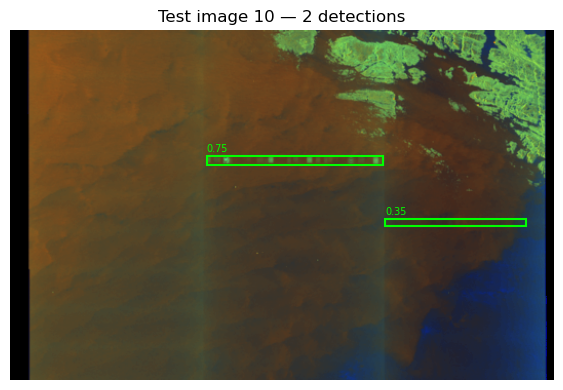

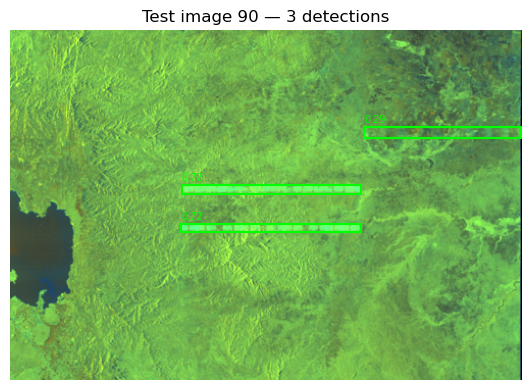

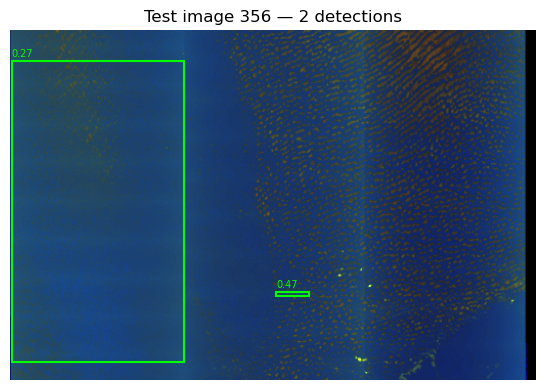

In [13]:
import matplotlib.patches as mpatches

sample_ids = [10, 90, 356]
det_by_id  = defaultdict(list)
for d in detections:
    det_by_id[d["image_id"]].append(d)

for sid in sample_ids:
    img_path = IMG_TEST / f"{sid}.png"
    if not img_path.exists():
        continue
    img = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(10, 4))
    ax.imshow(img)
    for d in det_by_id[sid]:
        x, y, w, h = d["bbox"]
        rect = mpatches.Rectangle((x, y), w, h,
                                   linewidth=1.5, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 2, f"{d['score']:.2f}", color="lime", fontsize=7, va="bottom")
    ax.set_title(f"Test image {sid} — {len(det_by_id[sid])} detections")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Wrap-up

Baseline done. **Val mAP@0.50:0.95 = 0.4285** — better than I expected for a first pass. The P2 head clearly earned its keep.

A few takeaways before moving on:
- The pipeline (COCO conversion → split → train → val → submission) is solid and worth reusing as-is for the next experiments
- 0.43 is a reasonable floor, but the model still misses a lot of thin stripes. Going wider in architecture (more params, transformer attention) should help
- Need to revisit the confidence threshold for submission — 0.15 is probably too aggressive

**Next:** Phase 2 — try a 4th positional input channel (encoding x-position explicitly) and see if it helps. Then start playing with RT-DETR.

### Freeing GPU memory

Cleaning up before the next phase — the RTX 5080 has 16GB and I don't want stale references holding onto VRAM when I open the next notebook.

In [27]:
import torch, gc
del model, model_best
gc.collect()
torch.cuda.empty_cache()